In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np

from ml_tools.models.model_loss import MSELoss
from ml_tools.models.optimizers import SGD, Adam
from ml_tools.models.layers.layers import (
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
    RMSNormLayer
)
from ml_tools.models.layers.operators import LatentStack, LatentSum, ShiftRight
from ml_tools.models.layers.mixture_layers import PoolingLayer
from ml_tools.models.layers.fft_layers import FrequencyFFT
from ml_tools.models.layers.spectre_layers import SpectreAttention, SpectreDecoderAttention
from ml_tools.models.embedding.positional import SinusoidEmbedding

import matplotlib.pyplot as plt

MAX_POSSIBLE_WINDOWS = 2**10


In [2]:
from ml_tools.encoders.audio_encoders import (AudioProcessor,
                                              read_wav,
                                              window_size_from_ms,
                                              plot_waveform,
                                              plot_spectrogram,
                                              plot_window_spectra,
                                              build_windows,
                                              progressive_downsample)

WINDOW_LENGTH_MS = 800 # our window length
sample_rate, waveform_l = read_wav("../test.wav", channel=0)
sample_rate, waveform_r = read_wav("../test.wav", channel=1)

time_per_sample = 1000 / sample_rate
samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
# samples_per_window = WINDOW_LENGTH_MS / time_per_sample
real_positive_fft_shape = (samples_per_window // 2) + 1


print(time_per_sample, "ms per sample step")
print(f"Each {WINDOW_LENGTH_MS} ms window will be composed of {samples_per_window} samples")
print(f"Fourier Transform will yield {real_positive_fft_shape} frequency bins")

audio_enc = AudioProcessor(
    sample_rate=sample_rate,
    window_ms = WINDOW_LENGTH_MS,
    overlap_ratio= 1/3, # how much of the window is overlapping with previous step
    use_decibels = True,
    target = "waveform",
    variable_idx = 0
)


encoded_data = audio_enc.fit_encode(waveform_l)
print(audio_enc.metadata)
print("amplitude", encoded_data["amplitude"].shape, "\nfrequency spectrum:", encoded_data["spectrum"].shape)


0.010416666666666666 ms per sample step
Each 800 ms window will be composed of 76800 samples
Fourier Transform will yield 38401 frequency bins
{'target': 'waveform', 'variable_idx': 0, 'sample_rate': 96000, 'window_ms': 800, 'window_size': 76800, 'num_overlap': 25600, 'num_frequencies': 537614, 'use_decibels': True}
amplitude (14, 76800) 
frequency spectrum: (14, 38401)


/Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/encoders/audio_encoders.py:115: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, waveform = wavfile.read(file_path)


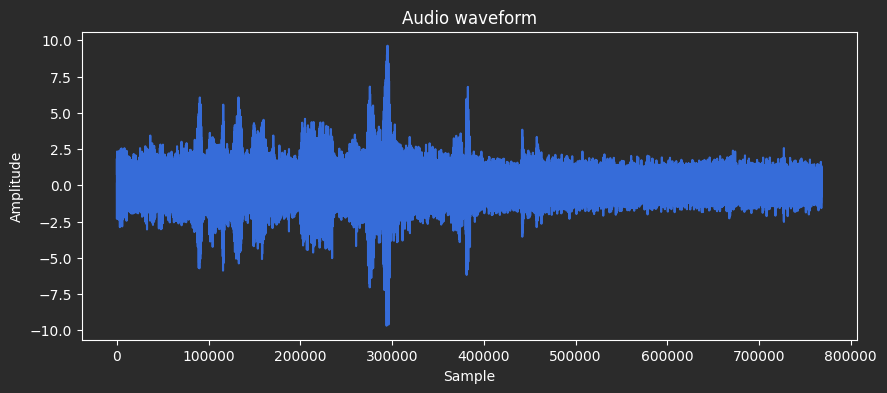

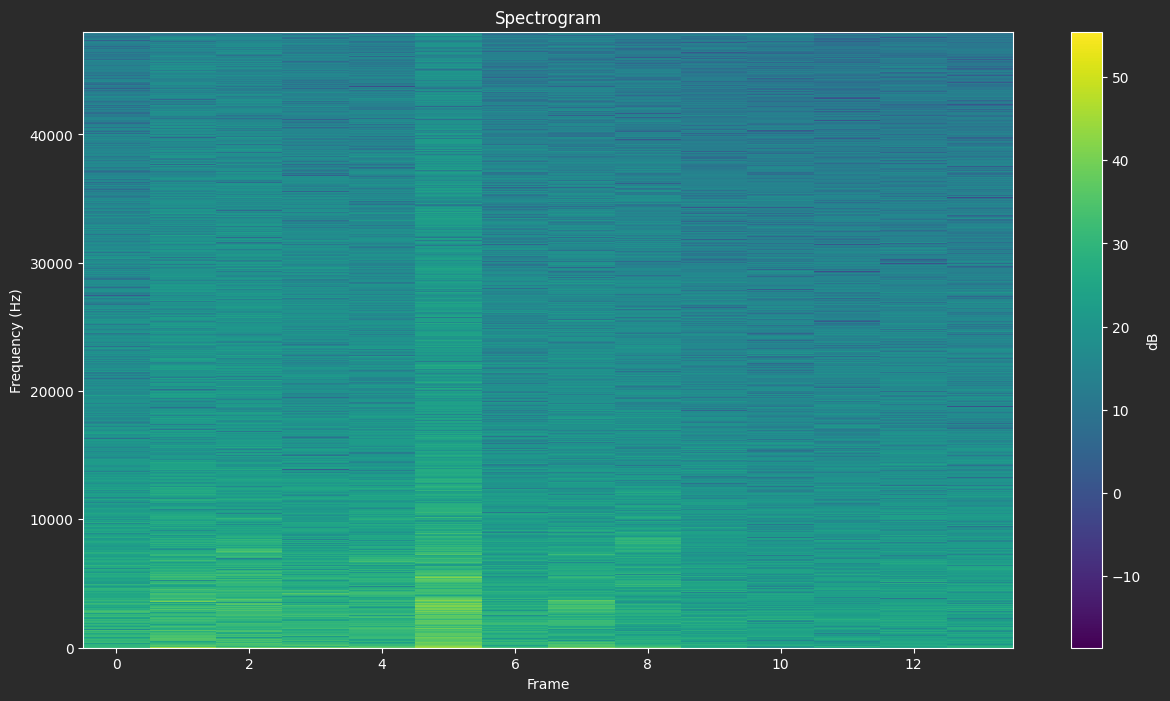

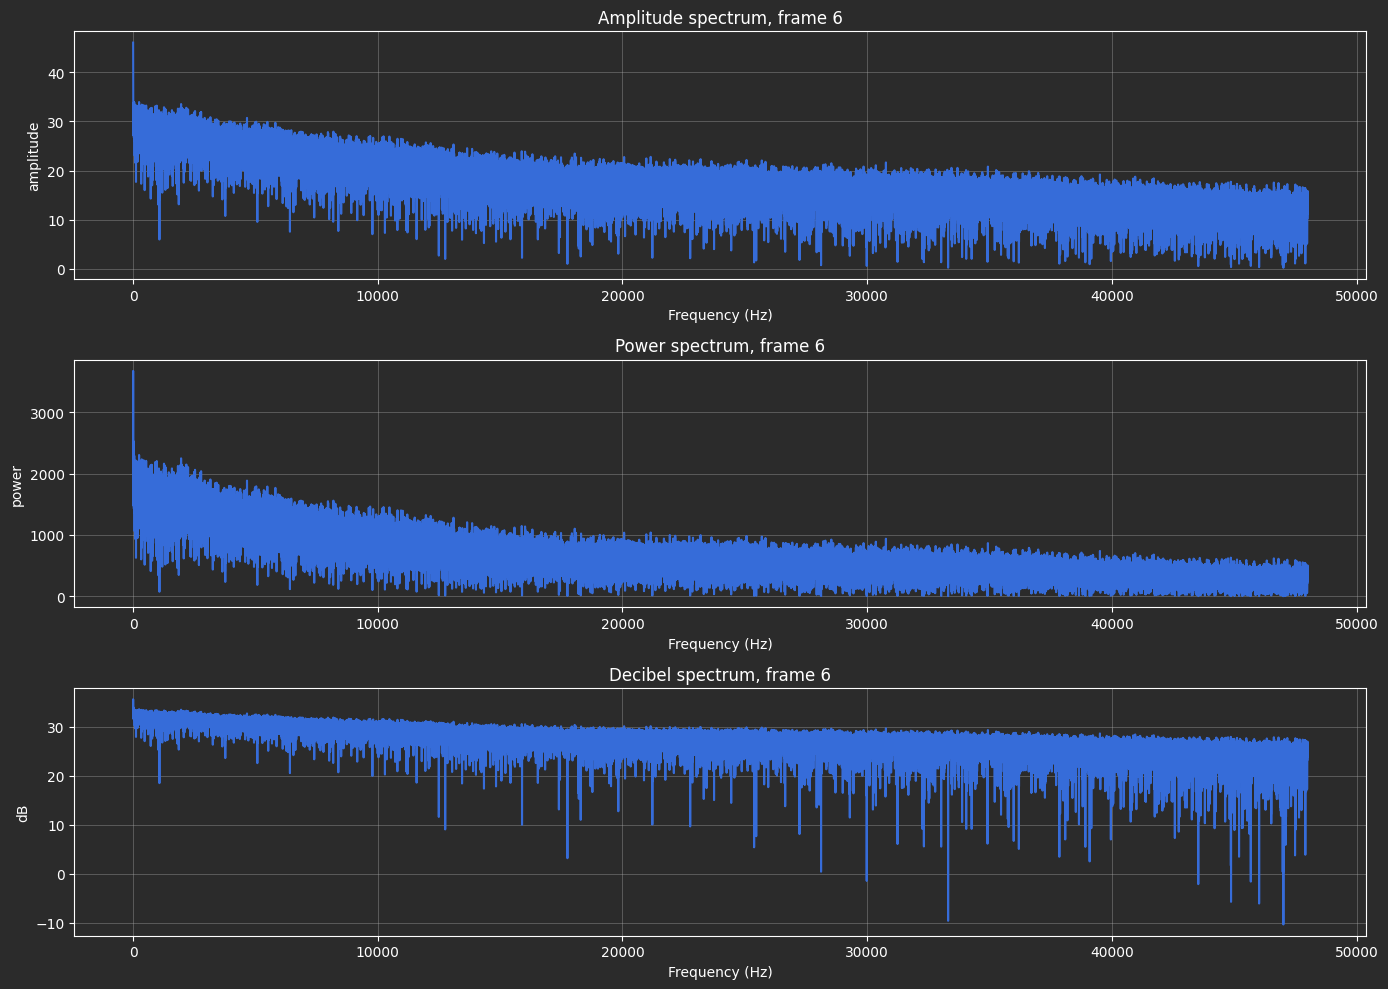

In [3]:
plot_waveform(waveform_l)
plot_spectrogram(encoded_data["spectrum"].real, audio_enc.freqs)
plot_window_spectra(
        encoded_data["spectrum"].real, audio_enc.freqs, index=6, window_size=time_per_sample
    )


In [4]:
# loading our audio files:
import os
WINDOW_LENGTH_MS = 100 # our window length

all_windowed_data = []

all_filenames = os.listdir(f"../data/")
for fn in all_filenames:
    if fn.endswith(".wav"):

        sample_rate, waveform_l = read_wav(f"../data/{fn}", channel=0)
        time_per_sample = 1000 / sample_rate
        samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
        # samples_per_window = WINDOW_LENGTH_MS / time_per_sample
        real_positive_fft_shape = (samples_per_window // 2) + 1


        audio_enc = AudioProcessor(
            sample_rate=sample_rate,
            window_ms = WINDOW_LENGTH_MS,
            overlap_ratio= 1/3, # how much of the window is overlapping with previous step
            use_decibels = True,
            target = "waveform",
            variable_idx = 0
        )

        encoded_data_l = audio_enc.fit_encode(waveform_l)["amplitude"]
        list_of_array = [encoded_data_l]

        try:
            sample_rate, waveform_r = read_wav(f"../data/{fn}", channel=1)
            encoded_data_r = audio_enc.fit_encode(waveform_r)["amplitude"]
            list_of_array.append(encoded_data_r)
        except:
            pass

        all_windowed_data.extend(list_of_array)

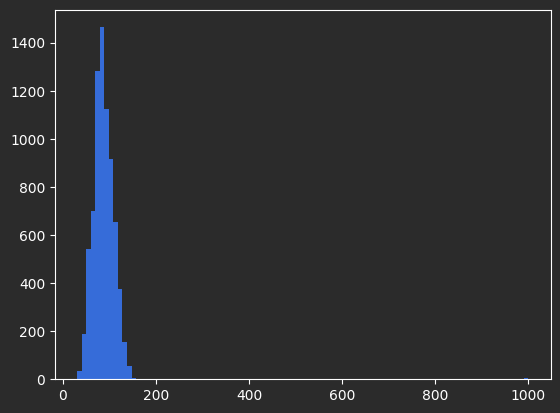

2214


In [5]:
shapes = []
np.random.shuffle(all_windowed_data)

for windowed_data in all_windowed_data:
    shapes.append(windowed_data.shape[0])

plt.hist(np.clip(shapes, min=0, max=1000), bins=100)
plt.show()
print(np.max(shapes))

In [6]:
# MAX_POSSIBLE_WINDOWS should be optimized for specific lengths of FFT: closest to: (2**10 * N)
MAX_POSSIBLE_WINDOWS = 2**10 * 1


# pad our sequences to max:
xs = np.zeros((len(all_windowed_data), MAX_POSSIBLE_WINDOWS, samples_per_window))
padding_mask = np.zeros((len(all_windowed_data), MAX_POSSIBLE_WINDOWS))
for idx, data in enumerate(all_windowed_data):
    l, n = data.shape
    l = min(l, MAX_POSSIBLE_WINDOWS)
    xs[idx, :l, :] = data[:l, ...]
    padding_mask[idx, :l] = 1

print(xs.shape)
print(padding_mask.shape)

(7504, 1024, 400)
(7504, 1024)


In [7]:
# downsample the data -- this could be helpful? or not... not sure yet.
#
# downs = progressive_downsample(xs, mask=padding_mask, factors=[2, 2, 2])
#
# for dim in downs:
#     print(dim[0].shape, dim[1].shape)

In [8]:
print(xs.shape, padding_mask.shape)

(7504, 1024, 400) (7504, 1024)


In [9]:
MAX_POSSIBLE_WINDOWS

1024

edges:
  input      -> amp_a
  amp_a      -> amp_b
  amp_b      -> amp_c
  input      -> freq_fft
  freq_fft   -> freq_fc
  amp_c      -> stack
  freq_fc    -> stack
  stack      -> position
  position   -> project
  project    -> enc1_attn
  enc1_attn  -> enc1_drop
  enc1_drop  -> enc1_a
  project    -> enc2_latentconn
  enc1_a     -> enc2_latentconn
  enc2_latentconn -> enc2_prenorm
  enc2_prenorm -> enc2_attn
  enc2_attn  -> enc2_drop
  enc2_drop  -> enc2_a
  project    -> enc3_latentconn
  enc2_a     -> enc3_latentconn
  enc3_latentconn -> enc3_prenorm
  enc3_prenorm -> enc3_attn
  enc3_attn  -> enc3_drop
  enc3_drop  -> enc3_a
  project    -> latentresid
  enc3_a     -> latentresid
  latentresid -> latent_prenorm
  latent_prenorm -> latentproj
  latentproj -> pooler
  pooler     -> latent_norm
  project    -> shift_right
  shift_right -> teacher_dropout
  latent_norm -> decoder_projection
  decoder_projection -> decoder_input
  teacher_dropout -> decoder_input
  decoder_input -> p

<Axes: title={'center': 'audio_encoder_decoder'}>

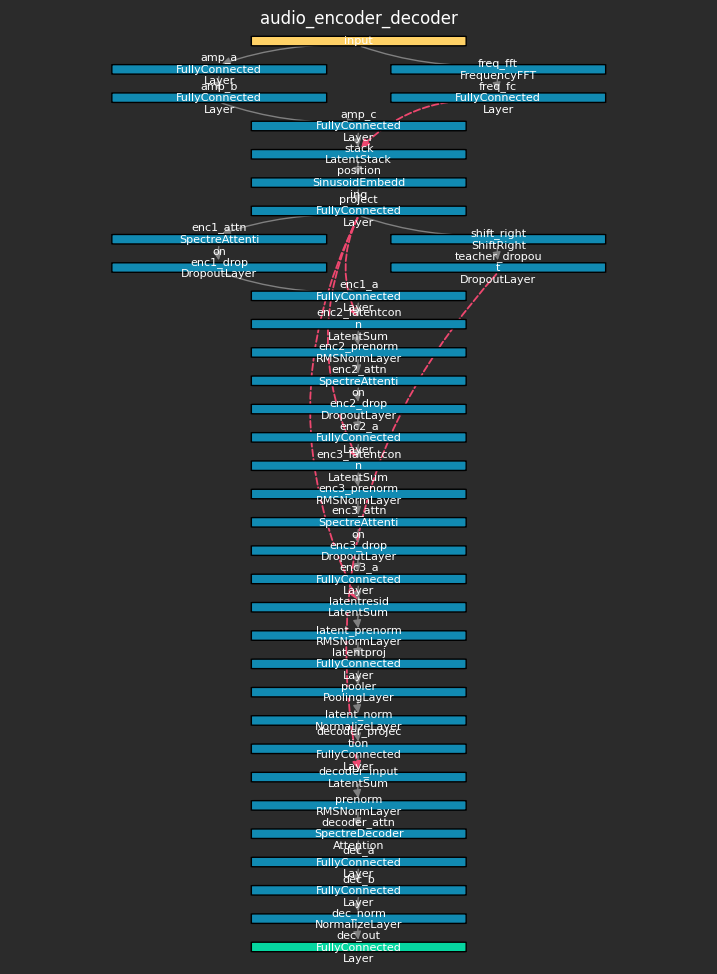

In [11]:
from ml_tools.models.neural_network import Node, NeuralNetwork
from ml_tools.visuals.nnet_visuals import plot_network

EMBEDDING_DIM = 800
HIDDEN_DIM = 512
NUM_HEADS=8
# latent space bottleneck
LATENT_DIMENSION = 1200

# samples_per_window = the samples per window (final dimesion of xs)

net = NeuralNetwork(name="audio_encoder_decoder", input_shape=((samples_per_window,),))
windows = net.input

# (num_samples, seq_length, window_dimension)

# amplitude branch: funnel the raw window down to the latent width
amplitude = net.connect(FullyConnectedLayer(samples_per_window, EMBEDDING_DIM, "relu"), windows, name="amp_a")
amplitude = net.connect(FullyConnectedLayer(EMBEDDING_DIM, real_positive_fft_shape, "relu"), amplitude, name="amp_b")
amplitude = net.connect(FullyConnectedLayer(real_positive_fft_shape, EMBEDDING_DIM, "linear"), amplitude, name="amp_c")

# frequency branch. `windows` is used a second time here, which is the fan-out
frequency = net.connect(FrequencyFFT(MAX_POSSIBLE_WINDOWS, samples_per_window), windows, name="freq_fft")
frequency = net.connect(FullyConnectedLayer(samples_per_window, EMBEDDING_DIM, "linear"), frequency, name="freq_fc")

# the branches merge, then get positional information
mixed = net.connect(LatentStack(), amplitude, frequency, name="stack")
mixed = net.connect(SinusoidEmbedding(MAX_POSSIBLE_WINDOWS, 2 * EMBEDDING_DIM), mixed, name="position")
mixed = net.connect(FullyConnectedLayer(2*EMBEDDING_DIM, HIDDEN_DIM, "linear"), mixed, name="project")

# encoder
enc1 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=2,
                                    memory_tokens=20,
                                    use_wrm=True), mixed, name="enc1_attn")
enc1 = net.connect(DropoutLayer(dropout_prob=0.05), enc1, name="enc1_drop")
enc1 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), enc1, name="enc1_a")

# encoder2 ------------------
enc2 = net.connect(LatentSum(), mixed, enc1, name="enc2_latentconn")
enc2 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc2, name="enc2_prenorm")
enc2 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=2,
                                    memory_tokens=20,
                                    use_wrm=True), enc2, name="enc2_attn")
enc2 = net.connect(DropoutLayer(dropout_prob=0.05), enc2, name="enc2_drop")
enc2 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), enc2, name="enc2_a")


#  encoder3 ------------------
enc3 = net.connect(LatentSum(), mixed, enc2, name="enc3_latentconn")
enc3 = net.connect(RMSNormLayer(ni=HIDDEN_DIM), enc3, name="enc3_prenorm")
enc3 = net.connect(SpectreAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                    hidden_dim=HIDDEN_DIM,
                                    num_heads=NUM_HEADS,
                                    band_radius=2,
                                    memory_tokens=20,
                                    use_wrm=True), enc3, name="enc3_attn")
enc3 = net.connect(DropoutLayer(dropout_prob=0.05), enc3, name="enc3_drop")
enc3 = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), enc3, name="enc3_a")


#  Latent ------------------
latent = net.connect(LatentSum(), mixed, enc3, name="latentresid")
latent = net.connect(RMSNormLayer(HIDDEN_DIM), latent, name="latent_prenorm")
latent = net.connect(FullyConnectedLayer(HIDDEN_DIM, LATENT_DIMENSION, "linear"), latent, name="latentproj")
pooler = net.connect(PoolingLayer(), latent, name="pooler")
pooler = net.connect(NormalizeLayer(LATENT_DIMENSION), pooler, name="latent_norm")


# DECODER ------------------
shifted = net.connect(ShiftRight(hidden_dim=HIDDEN_DIM), mixed, name="shift_right")
shifted_noisy = net.connect(DropoutLayer(dropout_prob=0.33), shifted, name="teacher_dropout")

latent_broadcast = net.connect(FullyConnectedLayer(LATENT_DIMENSION, HIDDEN_DIM, "linear"), pooler,
                      name="decoder_projection")

decoded = net.connect(LatentSum(), latent_broadcast, shifted_noisy, name="decoder_input")
decoded = net.connect(RMSNormLayer(HIDDEN_DIM), decoded, name="prenorm")
decoded = net.connect(SpectreDecoderAttention(sequence_length=MAX_POSSIBLE_WINDOWS,
                                            hidden_dim=HIDDEN_DIM,
                                            num_heads=NUM_HEADS,
                                            band_radius=2,
                                            memory_tokens=20,
                                            use_wrm=True), decoded, name="decoder_attn")
decoded = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), decoded, name="dec_a")
decoded = net.connect(FullyConnectedLayer(HIDDEN_DIM, HIDDEN_DIM, "relu"), decoded, name="dec_b")
decoded = net.connect(NormalizeLayer(HIDDEN_DIM, shift_scale=True), decoded, name="dec_norm")
# CausalSpectreAttention
# TODO: reconstruct sequence
net.output = net.connect(FullyConnectedLayer(HIDDEN_DIM, samples_per_window, "linear", is_output=True), decoded, name="dec_out")


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
print()
print(net.summary(xs[0:2, :, :]))
print(net.timing_summary(top=10))
plot_network(net)


Automatic pdb calling has been turned ON
0, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    1  reconstruction loss 97.052028
0, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    1  reconstruction loss 89.474575
step    1  reconstruction loss 89.474575


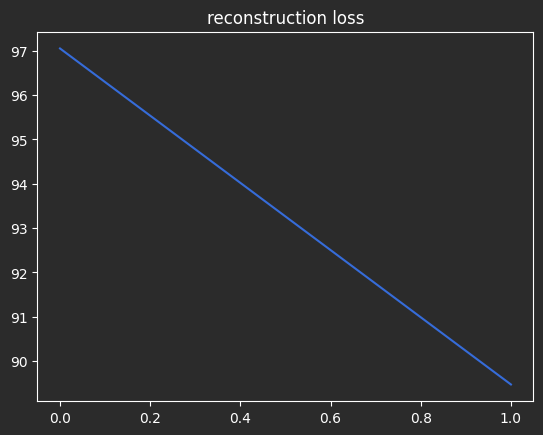

1, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    2  reconstruction loss 63.322387
1, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    2  reconstruction loss 61.579291
step    2  reconstruction loss 61.579291


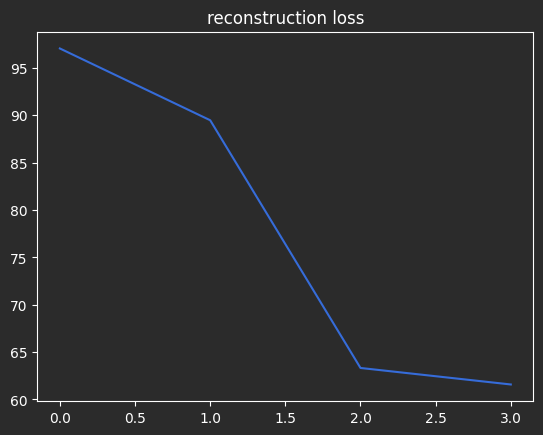

2, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    3  reconstruction loss 66.099047
2, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    3  reconstruction loss 64.153007
step    3  reconstruction loss 64.153007


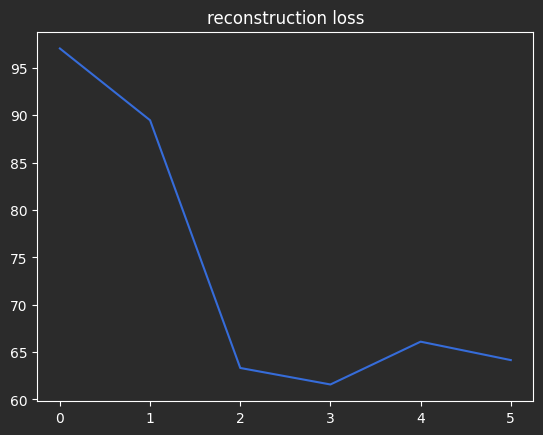

3, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    4  reconstruction loss 55.938083
3, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    4  reconstruction loss 55.281017
step    4  reconstruction loss 55.281017


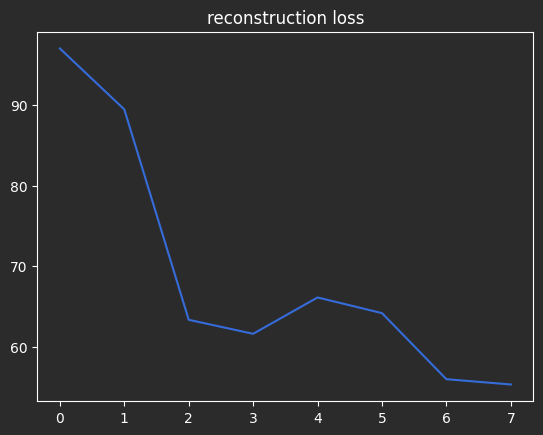

4, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    5  reconstruction loss 51.461902
4, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    5  reconstruction loss 51.043618
step    5  reconstruction loss 51.043618


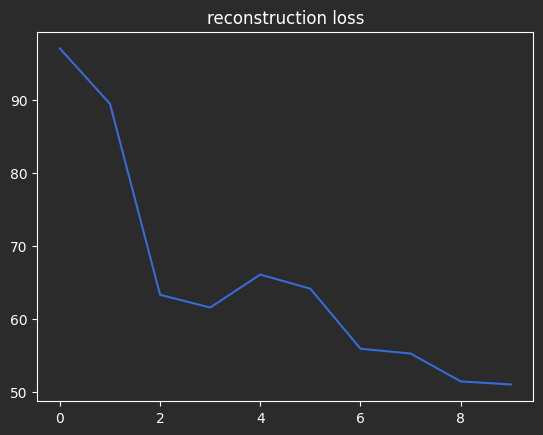

5, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    6  reconstruction loss 61.139462
5, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    6  reconstruction loss 60.423856
step    6  reconstruction loss 60.423856


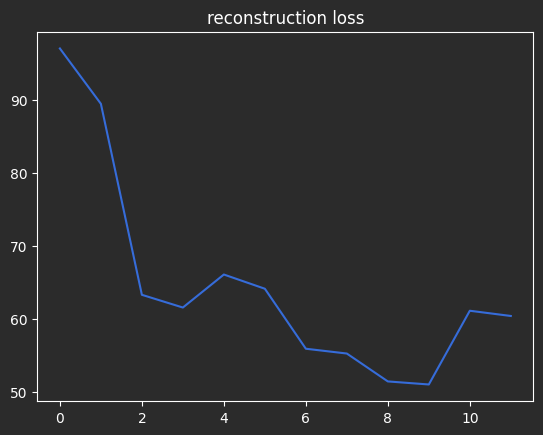

6, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    7  reconstruction loss 64.837017
6, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    7  reconstruction loss 64.453293
step    7  reconstruction loss 64.453293


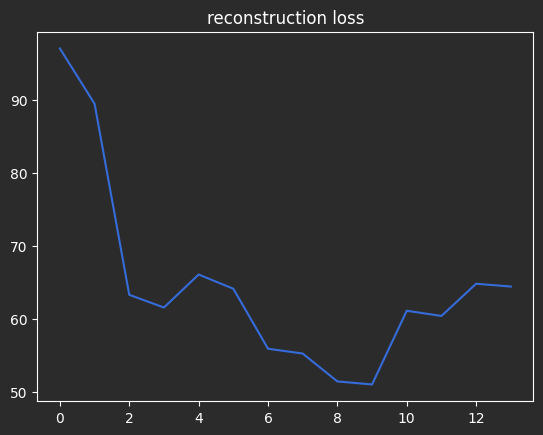

7, 0
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
step    8  reconstruction loss 55.950900
7, 1
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)
grad:  (25, 1024, 512)


KeyboardInterrupt: 

    [... skipping 1 hidden frame(s)]
  /var/folders/v1/q6fjybyj75s5vl9h5zylkbnw0000gp/T/ipykernel_39370/938752921.py(28)<module>()
     26             all_losses.append(reconstruction_loss.item())
     27 
---> 28             net.backward(loss.backward())
     29             optimizer.step(net.layers)
     30             print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
  /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/models/neural_network.py(434)backward()
    432                 continue
    433 
--> 434             returned = node.layer.backward(gradients.pop(node))
    435             self._record_timing(node.name, "backward", time.perf_counter() - start)
    436             parts = returned if len(node.sources) > 1 else (returned,)
  /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/models/layers/spectre_layers.py(686)backward()
    684         print("grad: ", incoming_gradient.shape)
    685         

In [13]:
# AND this is how we train:
%pdb on
BATCH_SIZE = 25
EPOCHS = 10
STEPS_PER_SAMPLE = 2
LR = 4e-4
DIVI = 10

loss = MSELoss()
optimizer = Adam(LR)
all_losses = []

net.train()
for epoch in range(EPOCHS):
    for step_i, batch_st in enumerate(range(4000, len(xs), BATCH_SIZE)):

        verbose = (step_i + 1) % DIVI == 0
        verbose = True

        _xs = xs[batch_st:batch_st+BATCH_SIZE, :, :]
        _pad = padding_mask[batch_st:batch_st+BATCH_SIZE, :]
        for _ in range(STEPS_PER_SAMPLE):
            print(f"{step_i}, {_}")
            x_prime = net.forward(_xs, mask=_pad)
            reconstruction_loss = loss.forward(prediction=x_prime, targets=_xs, mask=_pad)
            all_losses.append(reconstruction_loss.item())

            net.backward(loss.backward())
            optimizer.step(net.layers)
            print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")

        if verbose:
            print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
            plt.plot(all_losses)
            plt.title("reconstruction loss")
            plt.show()

plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

step    8  reconstruction loss 55.728860


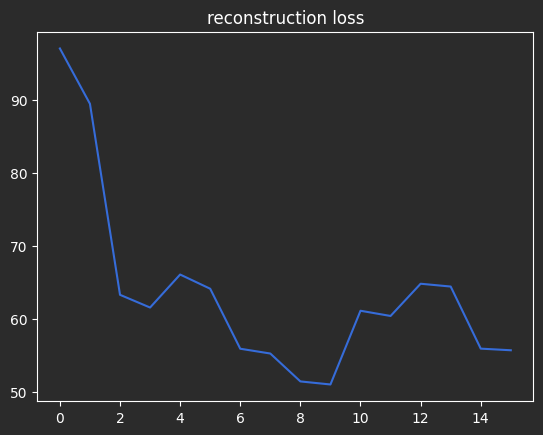

In [14]:
print(f"step {step_i + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")
plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

In [18]:
windowed_data.shape
x_prime.shape

(25, 1024, 400)

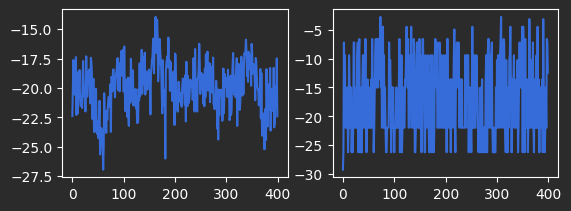

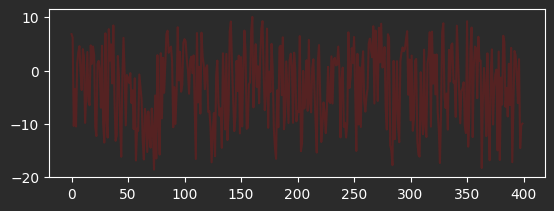

In [20]:
plt.figure()
plt.subplot(2,2, 1)
plt.plot(x_prime[0, 3, :])
plt.subplot(2,2, 2)
plt.plot(xs[0, 3, :])
plt.show()
plt.subplot(2,2, (3,4))
plt.plot((x_prime[0, 3, :] - xs[0, 3, :]), color="red", alpha=0.2)
plt.show()

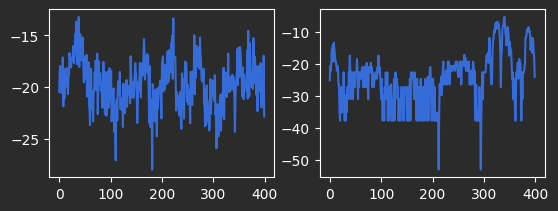

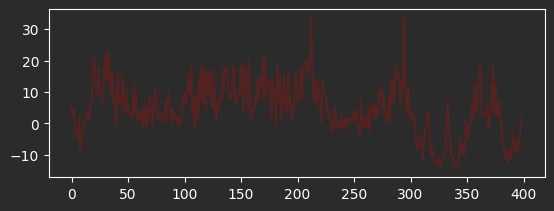

In [21]:
plt.figure()
plt.subplot(2,2, 1)
plt.plot(x_prime[5, 3, :])
plt.subplot(2,2, 2)
plt.plot(xs[5, 3, :])
plt.show()
plt.subplot(2,2, (3,4))
plt.plot((x_prime[5, 3, :] - xs[5, 3, :]), color="red", alpha=0.2)
plt.show()

In [ ]:
print(net.summary())